# <p align="center">**Laboratorio de Aprendizaje Estadístico**</p>

## <p align="center">**Profesor: Gabriel Alejandro Morales Ruiz**</p>

<p align="center">
  <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-Gris.png" alt="Descripción" width="550">
</p>

## <p align="center">Proyecto 3</p>

### <p align="center">Final</p>

### <p align="center">**Fecha:** 11 de mayo de 2026</p>

### <p align="center">**Integrantes:**</p>


<p align="center">Julieta Madrigal Flores</p>
<p align="center">Gibrán Leonardo Chávez González</p>
<p align="center">Diana Fernanda Barbosa Dueñas</p>

In [153]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RepeatedKFold 
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
import missingno as msgno

`RepeatedKFold` permite obtener una estimación más estable del desempeño al repetir varias particiones de k-folds cross-validation.

Esto es útil cuando el target tiene valores extremos, porque reduce la dependencia de una sola partición.

In [154]:
df = pd.read_csv('WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,Location Code,Marital Status,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,Suburban,Married,69,32,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,Suburban,Single,94,13,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,Suburban,Married,108,18,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,Suburban,Married,106,18,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,Rural,Single,73,12,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


<Axes: >

<Figure size 1500x1000 with 0 Axes>

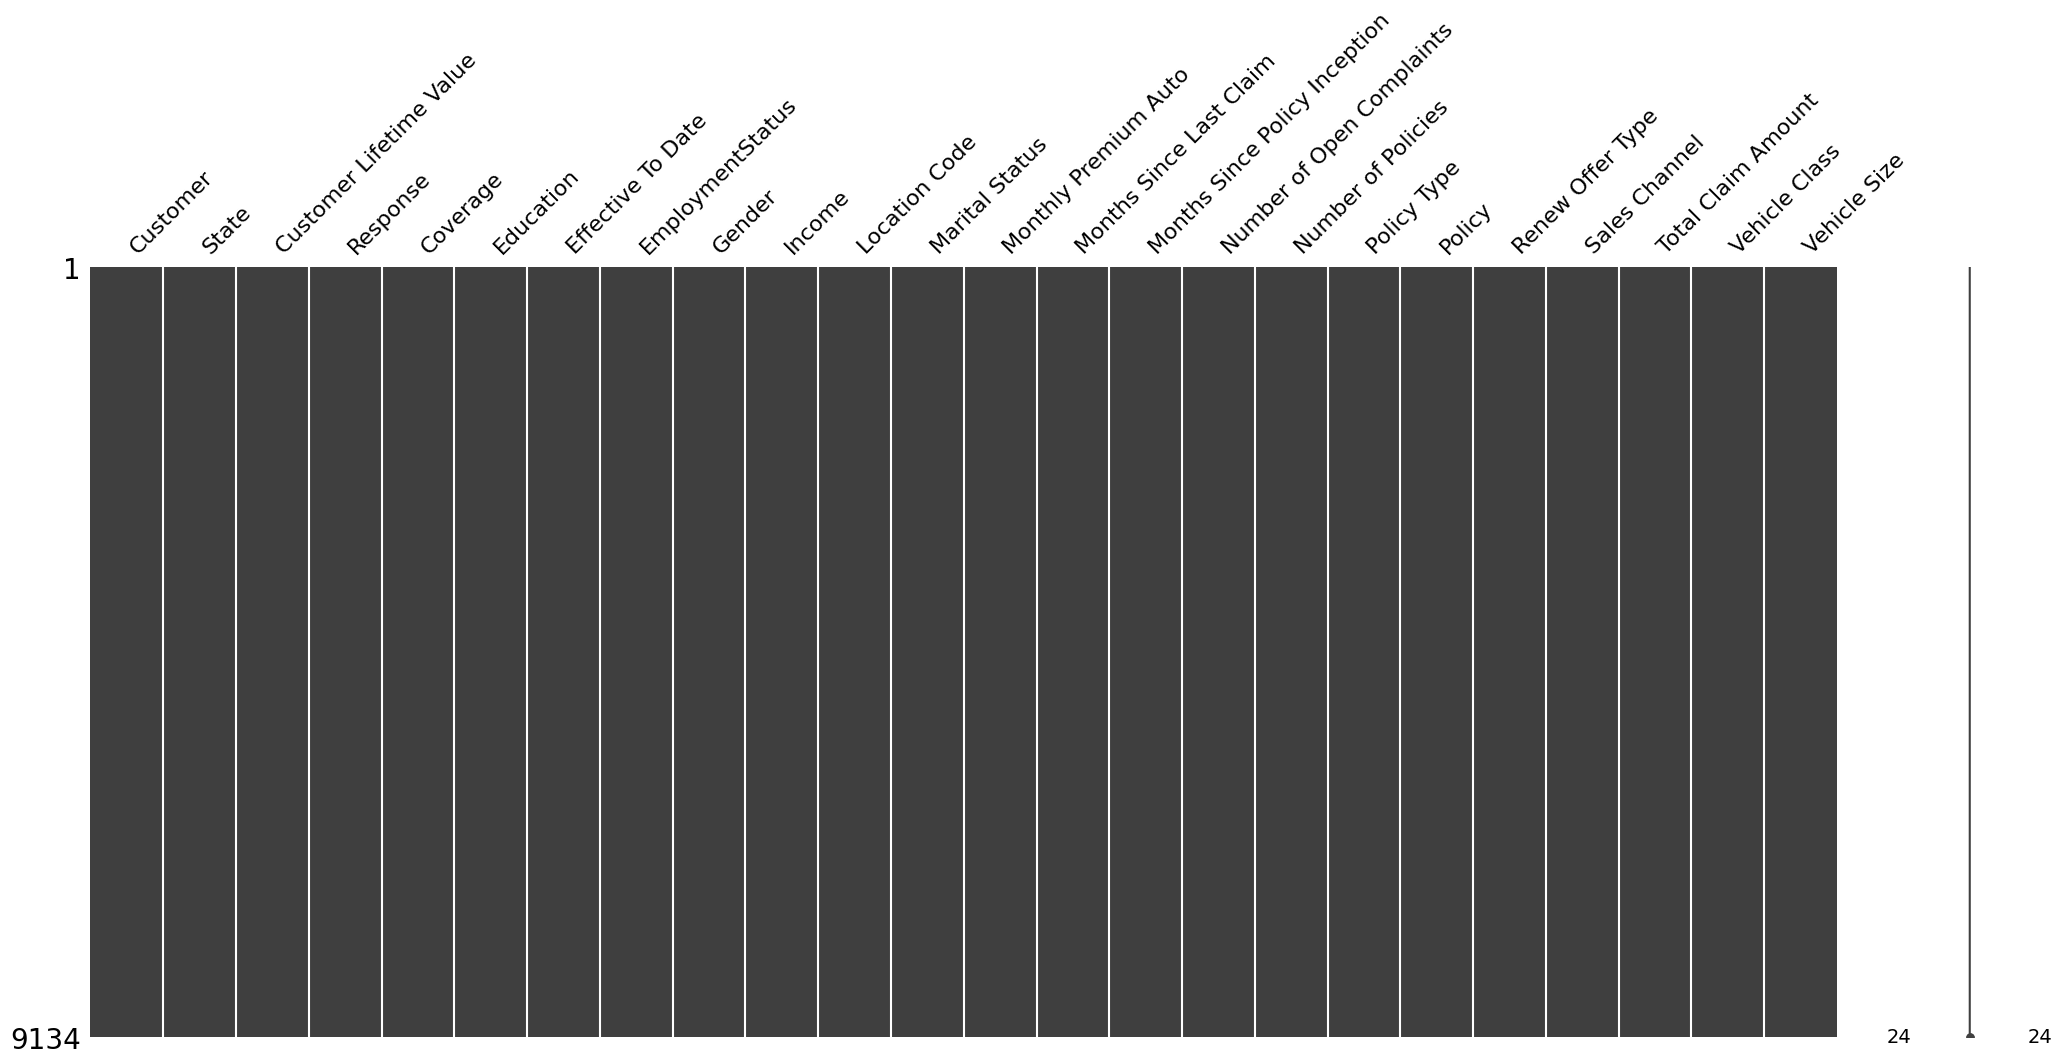

In [155]:
plt.figure(figsize=(15, 10))
msgno.matrix(df)

In [156]:
df.describe()

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,0.384388,2.966170,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,0.910384,2.390182,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.000000,1.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,0.000000,1.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,0.000000,2.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,0.000000,4.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,5.000000,9.000000,2893.239678


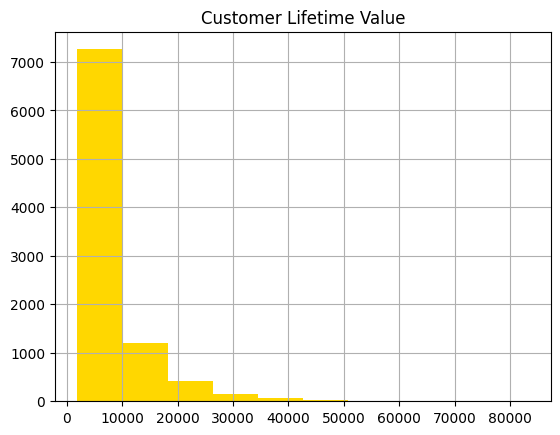

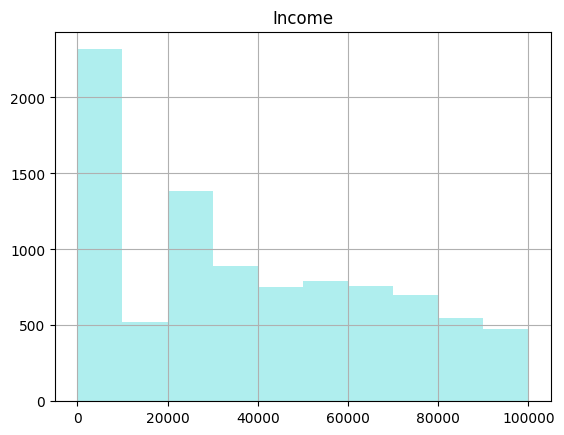

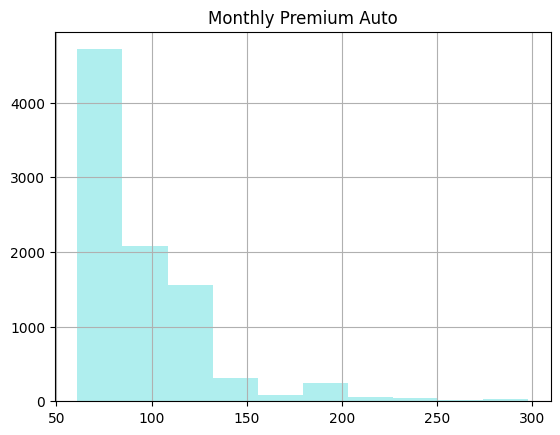

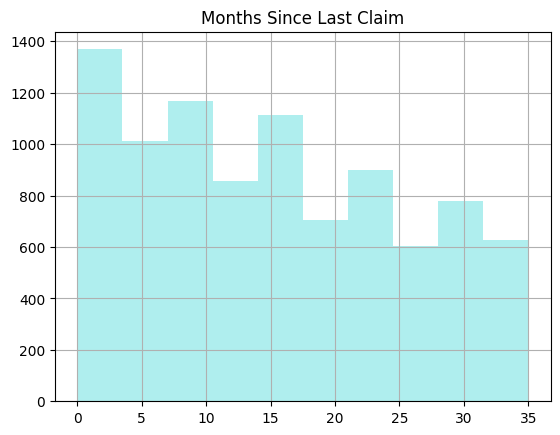

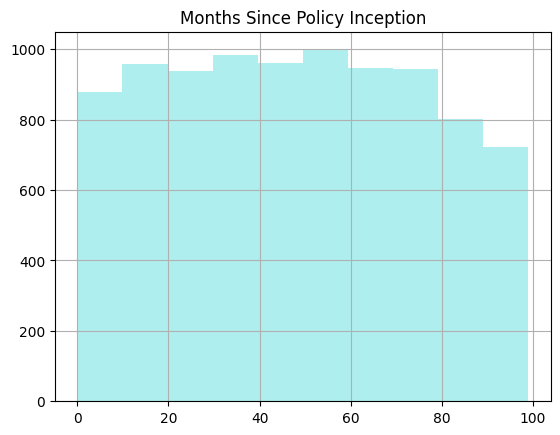

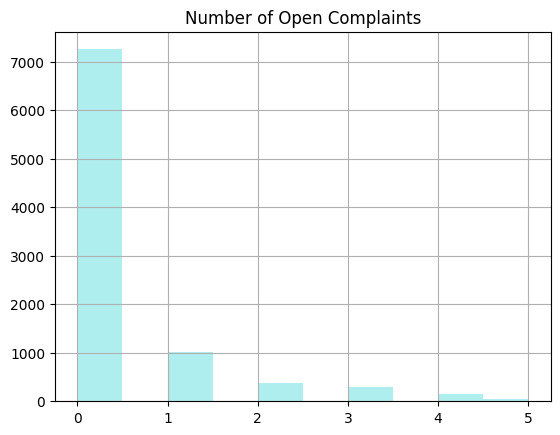

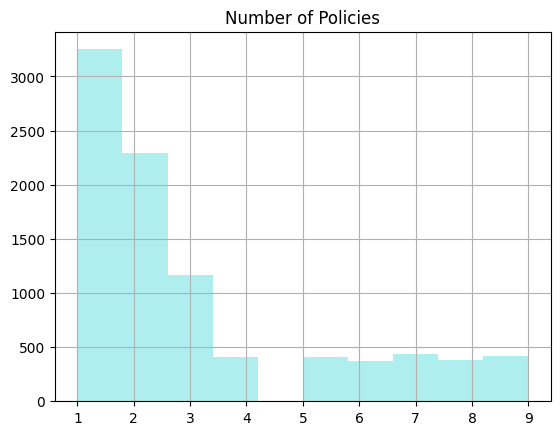

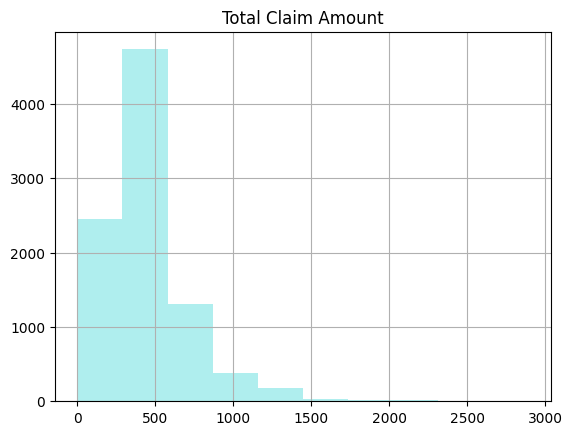

In [157]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.title(col)
    df[col].hist(color=('gold' if col == 'Customer Lifetime Value' else 'paleturquoise'))
    plt.show()

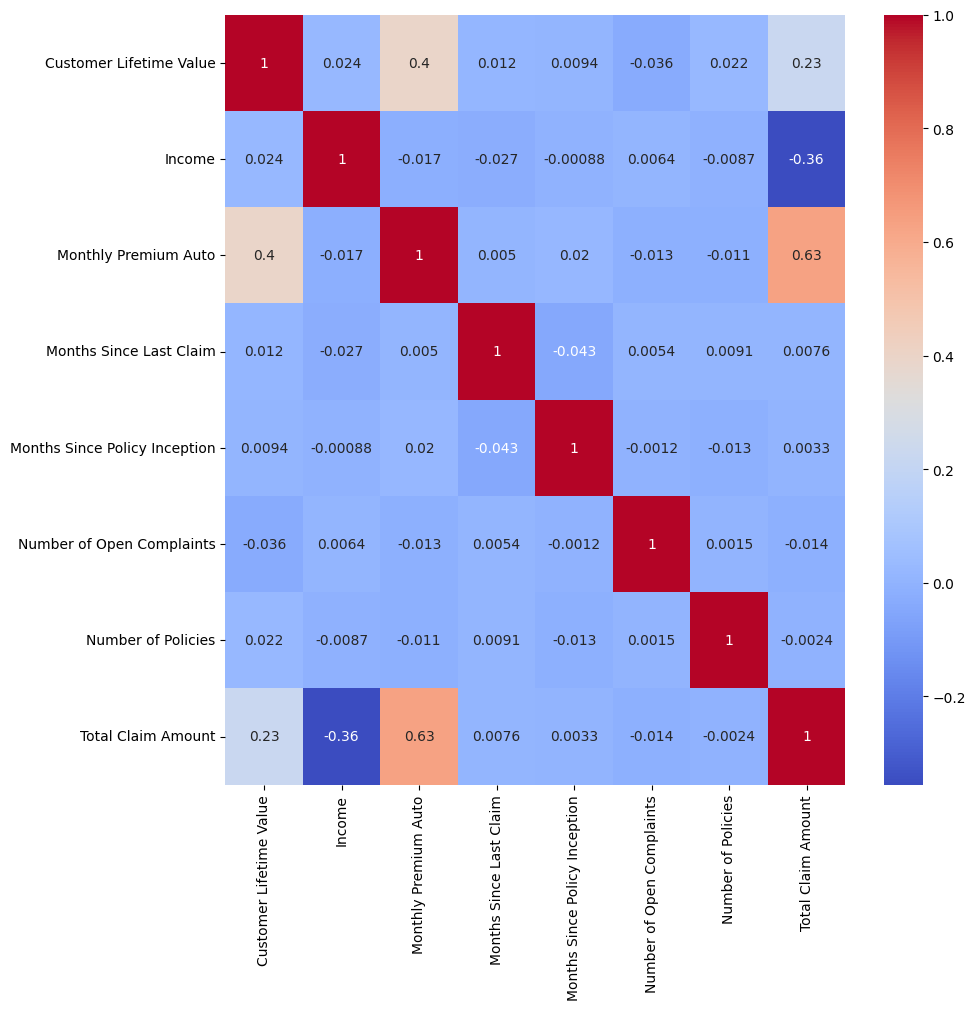

In [158]:
# Matriz de correlación
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [160]:
df['Effective To Date'] = pd.to_datetime(df['Effective To Date'])

C:\Users\gibra\AppData\Local\Temp\ipykernel_25564\1058590742.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Effective To Date'] = pd.to_datetime(df['Effective To Date'])


In [161]:
pr = min(df['Effective To Date'])
print(f'Primer registro en: {pr}')

Primer registro en: 2011-01-01 00:00:00


In [162]:
ur = max(df['Effective To Date'])
print(f'Último registro en: {ur}')

Último registro en: 2011-02-28 00:00:00


In [163]:
dif = max(df['Effective To Date']) - min(df['Effective To Date'])
print(f'Todos los registros fueron hechos en: {dif}')

Todos los registros fueron hechos en: 58 days 00:00:00


In [164]:
for col in df.columns:
    print(f'Únicos en columna {col}: {df[col].unique()} \n')

Únicos en columna Customer: ['BU79786' 'QZ44356' 'AI49188' ... 'TD14365' 'UP19263' 'Y167826'] 

Únicos en columna State: ['Washington' 'Arizona' 'Nevada' 'California' 'Oregon'] 

Únicos en columna Customer Lifetime Value: [ 2763.519279  6979.535903 12887.43165  ...  8163.890428  7524.442436
  2611.836866] 

Únicos en columna Response: ['No' 'Yes'] 

Únicos en columna Coverage: ['Basic' 'Extended' 'Premium'] 

Únicos en columna Education: ['Bachelor' 'College' 'Master' 'High School or Below' 'Doctor'] 

Únicos en columna Effective To Date: <DatetimeArray>
['2011-02-24 00:00:00', '2011-01-31 00:00:00', '2011-02-19 00:00:00',
 '2011-01-20 00:00:00', '2011-02-03 00:00:00', '2011-01-25 00:00:00',
 '2011-01-18 00:00:00', '2011-01-26 00:00:00', '2011-02-17 00:00:00',
 '2011-02-21 00:00:00', '2011-01-06 00:00:00', '2011-02-06 00:00:00',
 '2011-01-10 00:00:00', '2011-01-17 00:00:00', '2011-01-05 00:00:00',
 '2011-02-27 00:00:00', '2011-01-14 00:00:00', '2011-01-21 00:00:00',
 '2011-02-05 00:00:

In [165]:
target = 'Customer Lifetime Value'

num_cols = [ 
    'Income',
    'Monthly Premium Auto', 
    'Months Since Last Claim', 
    'Months Since Policy Inception', 
    'Number of Open Complaints', 
    'Number of Policies',
    'Total Claim Amount'
]

cat_cols = [
    'State',
    'Response',
    'Education',
    'EmploymentStatus',
    'Gender',
    'Location Code',
    'Marital Status',
    'Policy Type',
    'Policy',
    'Renew Offer Type',
    'Sales Channel',
    'Vehicle Class'
]

ordinal_cols = [
    'Coverage',
    'Vehicle Size'
]

In [166]:
X = df[num_cols + cat_cols + ordinal_cols]
y = df[target]

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Esto para probar el modelo final con datos no vistos

In [168]:
order = [
    ['Basic', 'Extended', 'Premium'],
    ['Small', 'Medsize', 'Large']
]

In [169]:
num_transformer = StandardScaler() 
cat_transformer = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)
ord_transformer = OrdinalEncoder(
    categories=order
)

In [170]:
transformer = ColumnTransformer(
    transformers=[
        ('numeric', num_transformer, num_cols),
        ('categoric', cat_transformer, cat_cols),
        ('ordinal', ord_transformer, ordinal_cols)
    ]
)

In [171]:
rdf_model = RandomForestRegressor(
    random_state=42, 
    n_jobs=-1 # Usa todos los núcleos disponibles de la computadora para paralelizar el trabajo
)

In [172]:
xgb_model = XGBRegressor(
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos disponibles de la computadora para paralelizar el trabajo
)

In [173]:
pipeline_rdf = Pipeline(
    steps=[
        ('preprocessor', transformer),
        ('model', rdf_model)
    ]
)

In [174]:
search_space_rdf = {
    'model__n_estimators': Integer(100, 1000), # Número de árboles
    'model__max_depth': Integer(2, 30), # Controla qué tan profundos pueden ser los árboles
    'model__min_samples_split': Integer(2, 30), # Controla cuántas observaciones mínimas se necesitan para dividir un nodo  
    'model__min_samples_leaf': Integer(1, 20), # Controla cuántas observaciones mínimas debe tener una hoja final
    'model__max_features': Categorical(['sqrt', 'log2', None]), # Controla cuántas variables puede revisar cada árbol en cada división
    'model__bootstrap': Categorical([True, False]) # Controla y usa bootstrap o no
}

In [175]:
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

In [176]:
opt_rdf = BayesSearchCV(
    estimator=pipeline_rdf,
    search_spaces=search_space_rdf,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [177]:
opt_rdf.fit(X_train, y_train)

Fitting 15 folds for each of 1 candidates, totalling 15 fits


Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for eac

,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'model__bootstrap': Categorical(c...), prior=None), 'model__max_depth': Integer(low=2...m='normalize'), 'model__max_features': Categorical(c...), prior=None), 'model__min_samples_leaf': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,RepeatedKFold...ndom_state=42)


In [178]:
print('Mejores hiperparámetros de Random Forest:')
print(opt_rdf.best_params_, '\n')

print(f'Mejor RMSE de cross-validation: {-opt_rdf.best_score_}')

Mejores hiperparámetros de Random Forest:
OrderedDict([('model__bootstrap', True), ('model__max_depth', 27), ('model__max_features', None), ('model__min_samples_leaf', 6), ('model__min_samples_split', 13), ('model__n_estimators', 100)]) 

Mejor RMSE de cross-validation: 3669.45200024267


In [179]:
pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', transformer),
        ('model', xgb_model)
    ]
)

In [180]:
search_space_xgb = {
    'model__n_estimators': Integer(100, 1000), # Número de árboles
    'model__learning_rate': Real(0.01, 0.3, prior='log-uniform'), # Controla qué tan fuerte aprende cada árbol nuevo
    'model__max_depth': Integer(2, 12), # Controla qué tan complejos son los árboles.
    'model__min_child_weight': Integer(1, 20), # Hace que el modelo sea más conservador. Evita crear hojas con poca información.
    'model__subsample': Real(0.5, 1.0), # Porcentaje de filas usadas en cada árbol
    'model__colsample_bytree': Real(0.5, 1.0), # Porcentaje de columnas usadas por cada árbol
    'model__reg_alpha': Real(1e-8, 10.0, prior='log-uniform'), # Porcentaje de regularización L1
    'model__reg_lambda': Real(1e-8, 10.0, prior='log-uniform') # Porcentaje de regularización L1
}

In [181]:
opt_xgb = BayesSearchCV(
    estimator=pipeline_xgb,
    search_spaces=search_space_xgb,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [182]:
opt_xgb.fit(X_train, y_train)

Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for each of 1 candidates, totalling 15 fits
Fitting 15 folds for eac

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'model__colsample_bytree': Real(low=0.5,...m='normalize'), 'model__learning_rate': Real(low=0.01...m='normalize'), 'model__max_depth': Integer(low=2...m='normalize'), 'model__min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,30
,scoring,'neg_root_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,RepeatedKFold...ndom_state=42)


In [183]:
print('Mejores hiperparámetros de XGBoost:')
print(opt_xgb.best_params_, '\n')

print(f'Mejor RMSE de cross-validation: {-opt_xgb.best_score_}')

Mejores hiperparámetros de XGBoost:
OrderedDict([('model__colsample_bytree', 0.848917701067587), ('model__learning_rate', 0.017461929617019596), ('model__max_depth', 9), ('model__min_child_weight', 19), ('model__n_estimators', 572), ('model__reg_alpha', 0.024200159521486957), ('model__reg_lambda', 0.6172611491593121), ('model__subsample', 0.919665724039493)]) 

Mejor RMSE de cross-validation: 3699.491031544445


In [184]:
best_rdf = opt_rdf.best_estimator_
best_rdf

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [185]:
best_xgb = opt_xgb.best_estimator_
best_xgb

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categoric', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [186]:
def evaluar_modelo(modelo, X_test, y_test, nombre):
    'Función que trabaja con un modelo, una matriz X y un vector y para dar diferentes scores: RMSE, MAE y R^2'
    y_pred = modelo.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'Modelo': nombre,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    }

In [187]:
metricas = pd.DataFrame([
    evaluar_modelo(best_rdf, X_test, y_test, 'Random Forest'),
    evaluar_modelo(best_xgb, X_test, y_test, 'XGBoost')
])

metricas

,Modelo,RMSE,MAE,R²
0,Random Forest,3981.436276,1506.012783,0.692413
1,XGBoost,4050.968811,1578.047699,0.681576


In [188]:
modelos_optimizados_cv = {
    'Random Forest': best_rdf,
    'XGBoost': best_xgb
}

resultados_optimizados_cv = []

In [189]:
for nombre, modelo in modelos_optimizados_cv.items():
    scores = cross_val_score(
        estimator=modelo,
        X=X_train,
        y=y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )

    rmse_scores = -scores

    resultados_optimizados_cv.append({
        'Modelo': nombre,
        'RMSE medio CV': rmse_scores.mean(),
        'Desviación estándar CV': rmse_scores.std()
    })

In [190]:
resultados_optimizados_cv = pd.DataFrame(resultados_optimizados_cv)
resultados_optimizados_cv

,Modelo,RMSE medio CV,Desviación estándar CV
0,Random Forest,3669.452000,189.336289
1,XGBoost,3699.491032,196.489846


In [191]:
tabla_final = pd.merge(
    metricas,
    resultados_optimizados_cv,
    on='Modelo',
    how='inner'
)

tabla_final

,Modelo,RMSE,MAE,R²,RMSE medio CV,Desviación estándar CV
0,Random Forest,3981.436276,1506.012783,0.692413,3669.452000,189.336289
1,XGBoost,4050.968811,1578.047699,0.681576,3699.491032,196.489846


In [192]:
def graficar_reales_vs_predichos(y_test, y_pred, nombre):
    plt.figure(figsize=(8, 6))
    
    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.6,
        color='lightblue'
    )
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    
    sns.lineplot(
        x=[min_val, max_val],
        y=[min_val, max_val],
        color='black',
        linestyle='--'
    )
    
    plt.xlabel('Valores reales')
    plt.ylabel('Valores predichos')
    plt.title(f'Reales vs Predichos - {nombre}')
    plt.show()

In [193]:
y_pred_rdf = best_rdf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

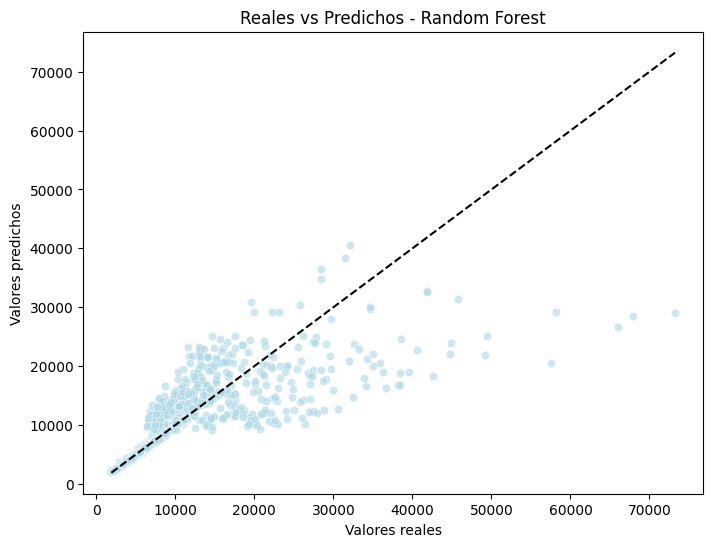

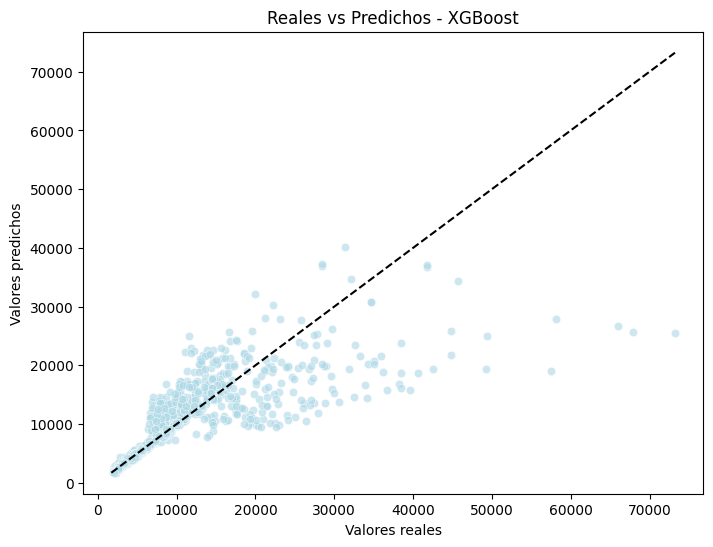

In [194]:
graficar_reales_vs_predichos(
    y_test=y_test,
    y_pred=y_pred_rdf,
    nombre='Random Forest'
)

graficar_reales_vs_predichos(
    y_test=y_test,
    y_pred=y_pred_xgb,
    nombre='XGBoost'
)

Las gráficas de valores reales contra valores predichos muestran que ambos modelos predicen razonablemente bien los valores bajos y medios de CLV. Sin embargo, para valores altos se observa subestimación, ya que varios puntos quedan por debajo de la línea ideal.

Para este proyecto se tomó el RMSE como métrica principal, ya que el objetivo es predecir el `Customer Lifetime Value`, una variable monetaria donde los errores grandes pueden tener mayor impacto en la toma de decisiones. El RMSE penaliza más fuertemente las predicciones muy alejadas del valor real, lo cual es importante porque el CLV presenta valores extremos. El MAE se utilizó como apoyo para interpretar el error promedio y el R² para evaluar la proporción de variabilidad explicada por el modelo.